In [41]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = create_engine("sqlite:///instacart.db")
conn= sqlite3.connect("instacart.db")

In [3]:
files = {
    "orders": r"C:\Users\shiva\Downloads\archive (5)\orders.csv",
    "products": r"C:\Users\shiva\Downloads\archive (5)\products.csv",
    "order_products_prior": r"C:\Users\shiva\Downloads\archive (5)\order_products__prior.csv",
    "order_products_train": r"C:\Users\shiva\Downloads\archive (5)\order_products__train.csv",
    "aisles": r"C:\Users\shiva\Downloads\archive (5)\aisles.csv",
    "departments": r"C:\Users\shiva\Downloads\archive (5)\departments.csv"
}

for table_name, file_path in files.items():
    df = pd.read_csv(file_path)
    df.to_sql(table_name,conn, if_exists="replace", index=False)

In [4]:
pd.read_sql("""
SELECT name 
FROM sqlite_master 
WHERE type='table';
""", conn)

,name
0,orders
1,products
2,order_products_prior
3,order_products_train
4,aisles
5,departments


# DATA INGESTION VALIDATION
### Rowcount_sanity
### REFERNTIAL_INTEGRITY
### DUPLICATES

In [5]:
tables = [
    "orders",
    "order_products_prior",
    "order_products_train",
    "products",
    "aisles",
    "departments"
]

for t in tables:
    count = pd.read_sql(f"SELECT COUNT(*) as cnt FROM {t}",conn)
    print(f"{t}: {count.iloc[0]['cnt']}")


orders: 3421083
order_products_prior: 32434489
order_products_train: 1384617
products: 49688
aisles: 134
departments: 21


In [16]:
query = """
SELECT COUNT(*) AS orphan_rows
FROM order_products_prior opp
LEFT JOIN orders o ON opp.order_id = o.order_id
WHERE o.order_id IS NULL;
"""
pd.read_sql(query,conn)

,orphan_rows
0,0


In [17]:
query = """
SELECT COUNT(*) AS orphan_rows
FROM order_products_train opt
LEFT JOIN orders o ON opt.order_id = o.order_id
WHERE o.order_id IS NULL;
"""
pd.read_sql(query,conn)

,orphan_rows
0,0


In [18]:
query = """
SELECT COUNT(*) AS orphan_rows
FROM order_products_prior opp
LEFT JOIN products o ON opp.product_id = o.product_id
WHERE o.product_id IS NULL;
"""
pd.read_sql(query,conn)

,orphan_rows
0,0


In [19]:
query = """
SELECT COUNT(*) AS orphan_rows
FROM order_products_train opt
LEFT JOIN products o ON opt.product_id = o.product_id
WHERE o.product_id IS NULL;
"""
pd.read_sql(query,conn)

,orphan_rows
0,0


In [20]:
query = """
SELECT COUNT(*) AS orphan_rows
FROM products p
LEFT JOIN aisles a ON p.aisle_id = a.aisle_id
WHERE a.aisle_id IS NULL;
"""
pd.read_sql(query,conn)

,orphan_rows
0,0


In [21]:
query = """
SELECT COUNT(*) AS orphan_rows
FROM products p
LEFT JOIN departments d ON p.department_id = d.department_id
WHERE d.department_id IS NULL;
"""
pd.read_sql(query,conn)

,orphan_rows
0,0


In [22]:
pd.read_sql("""SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS unique_orders
FROM orders;""",conn)


,total_rows,unique_orders
0,3421083,3421083


In [23]:
pd.read_sql("""SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT product_id) AS unique_products
FROM products;""",conn)


,total_rows,unique_products
0,49688,49688


In [24]:
pd.read_sql("""select count(*) as total_rows,count(aisle_id) from aisles""",conn)

,total_rows,count(aisle_id)
0,134,134


In [25]:
pd.read_sql("""select count(*) as total_rows ,count(department_id) from departments""",conn)

,total_rows,count(department_id)
0,21,21


In [26]:
pd.read_sql("""SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id || '-' || product_id) AS unique_pairs
FROM order_products_prior;""",conn)


,total_rows,unique_pairs
0,32434489,32434489


In [27]:
pd.read_sql("""SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id || '-' || product_id) AS unique_pairs
FROM order_products_train;""",conn)


,total_rows,unique_pairs
0,1384617,1384617


## 1)How active are users on the platform?

In [35]:
data=pd.read_sql(""" select user_id,count(order_id) as no_of_orders from orders group by user_id;""",conn)

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='no_of_orders', ylabel='Count'>

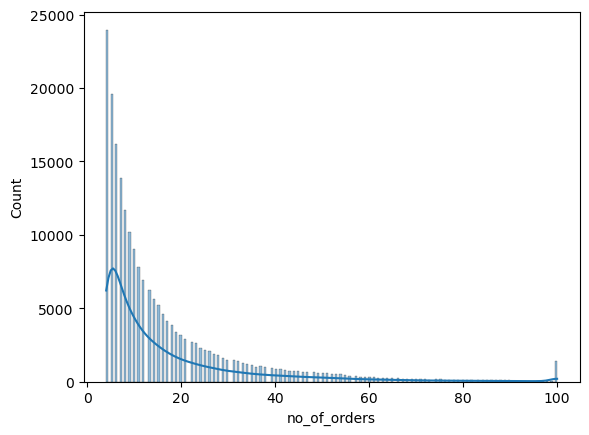

In [39]:
sns.histplot(x="no_of_orders",data=data,kde=True)

### User order counts exhibit a long-tailed distribution, indicating heterogeneous user activity with a large proportion of low-activity users(cold start users) and a smaller group of highly active users(power users). This confirms the need for personalized modeling while also motivating hierarchical backoff strategies for cold-start users.

## 2)How frequently do users place orders over time?(SHOPPING FREQUENCY)

In [52]:
data=pd.read_sql(""" select days_since_prior_order from orders""",conn)

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='days_since_prior_order', ylabel='Count'>

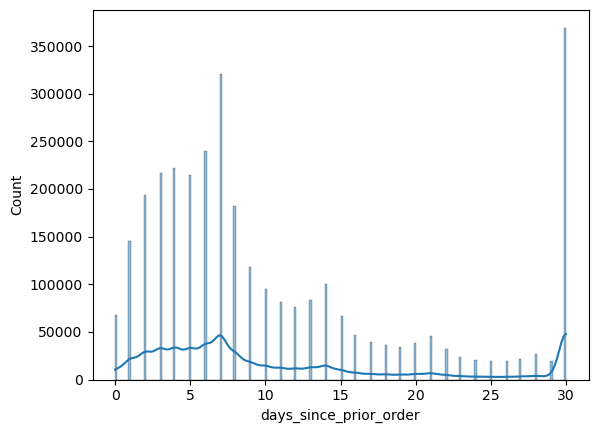

In [60]:
sns.histplot(x='days_since_prior_order',data=data,kde=True)

### User shopping frequency exhibits clear periodic behavior, with a strong weekly cycle and additional bi-weekly patterns, indicating habitual purchasing for many users. The spike at the maximum interval reflects a group of users with long or irregular shopping gaps rather than a strict monthly shopping cycle. This mixed behavior implies that both recency-based features and long-term aggregate features are necessary for effective reorder prediction.

## 3)Are product purchases / reorders concentrated among a small number of products, or evenly distributed?

In [73]:
prod_counts = pd.read_sql("""
    SELECT product_id,
           COUNT(*) AS total_occurrences
    FROM order_products_prior
    GROUP BY product_id
""", conn)

In [74]:
# sort by popularity
prod_counts = prod_counts.sort_values("total_occurrences")

# cumulative fraction of products
prod_counts["cum_products"] = np.arange(1, len(prod_counts) + 1) / len(prod_counts)

# cumulative fraction of reorder volume
prod_counts["cum_volume"] = prod_counts["total_occurrences"].cumsum()
prod_counts["cum_volume"] = prod_counts["cum_volume"] / prod_counts["total_occurrences"].sum()


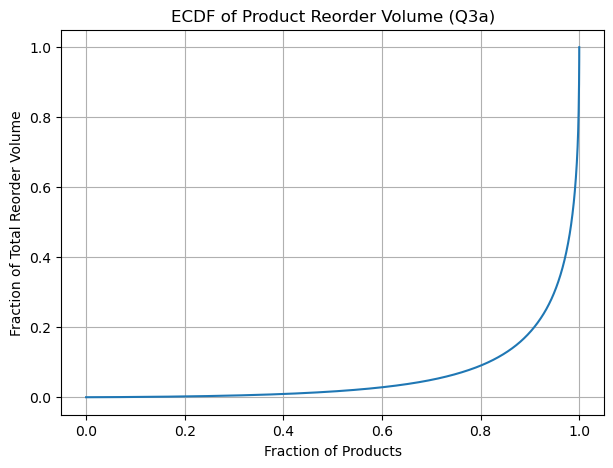

In [75]:
plt.figure(figsize=(7, 5))
plt.plot(
    prod_counts["cum_products"],
    prod_counts["cum_volume"]
)

plt.xlabel("Fraction of Products")
plt.ylabel("Fraction of Total Reorder Volume")
plt.title("ECDF of Product Reorder Volume (Q3a)")
plt.grid(True)
plt.show()


### A few products are reordered many times, while most products are reordered very rarely.This confirms strong product-level heterogeneity and the necessity of hierarchical backoff strategies.

## 4)Given that a product is purchased, how likely is it to be reordered?

In [76]:
prod_reorder_rate = pd.read_sql("""
    SELECT
        product_id,
        SUM(reordered) * 1.0 / COUNT(*) AS reorder_rate
    FROM order_products_prior
    GROUP BY product_id
""", conn)


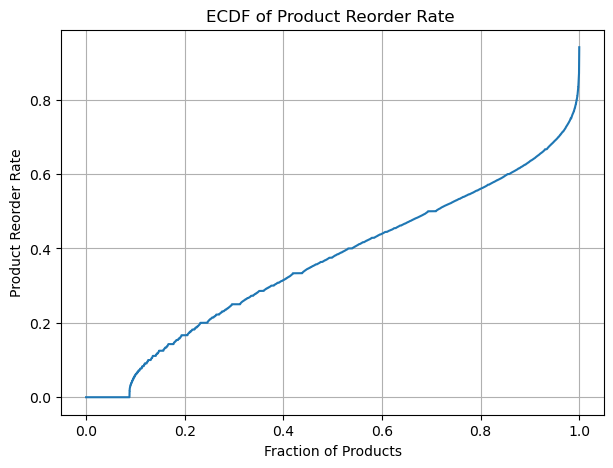

In [78]:
# sort by reorder rate
prod_reorder_rate = prod_reorder_rate.sort_values("reorder_rate")

# cumulative fraction of products
prod_reorder_rate["cum_products"] = (
    range(1, len(prod_reorder_rate) + 1)
)
prod_reorder_rate["cum_products"] /= len(prod_reorder_rate)

# ECDF plot
plt.figure(figsize=(7, 5))
plt.plot(
    prod_reorder_rate["cum_products"],
    prod_reorder_rate["reorder_rate"]
)

plt.xlabel("Fraction of Products")
plt.ylabel("Product Reorder Rate")
plt.title("ECDF of Product Reorder Rate ")
plt.grid(True)
plt.show()


### Some products are bought again and again, while many products are rarely bought more than once. This shows that people form strong buying habits for a small number of products, but most products are not part of regular shopping routines.

In [ ]:
user_product = pd.read_sql("""
    SELECT
        o.user_id,
        opp.product_id,
        COUNT(*) AS times_bought,
        SUM(opp.reordered) AS times_reordered
    FROM order_products_prior opp
    JOIN orders o
        ON opp.order_id = o.order_id
    GROUP BY o.user_id, opp.product_id
""", conn)

In [ ]:
import pandas as pd

data = pd.read_sql("""
    SELECT
        o.user_id,
        opp.product_id
    FROM order_products_prior opp
    JOIN orders o
        ON opp.order_id = o.order_id
    WHERE opp.reordered = 1
""", conn)
